# Single-cell Neighborhood Analysis

Based on the original neighborhood analysis pipeline, the single-cell neighborhood analysis filtered the windows to include only one cell type (paneth in this case).

In [1]:
!pip install scanpy

In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
import math
import os
from itertools import product

from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import scanpy as sc


##### Functions:

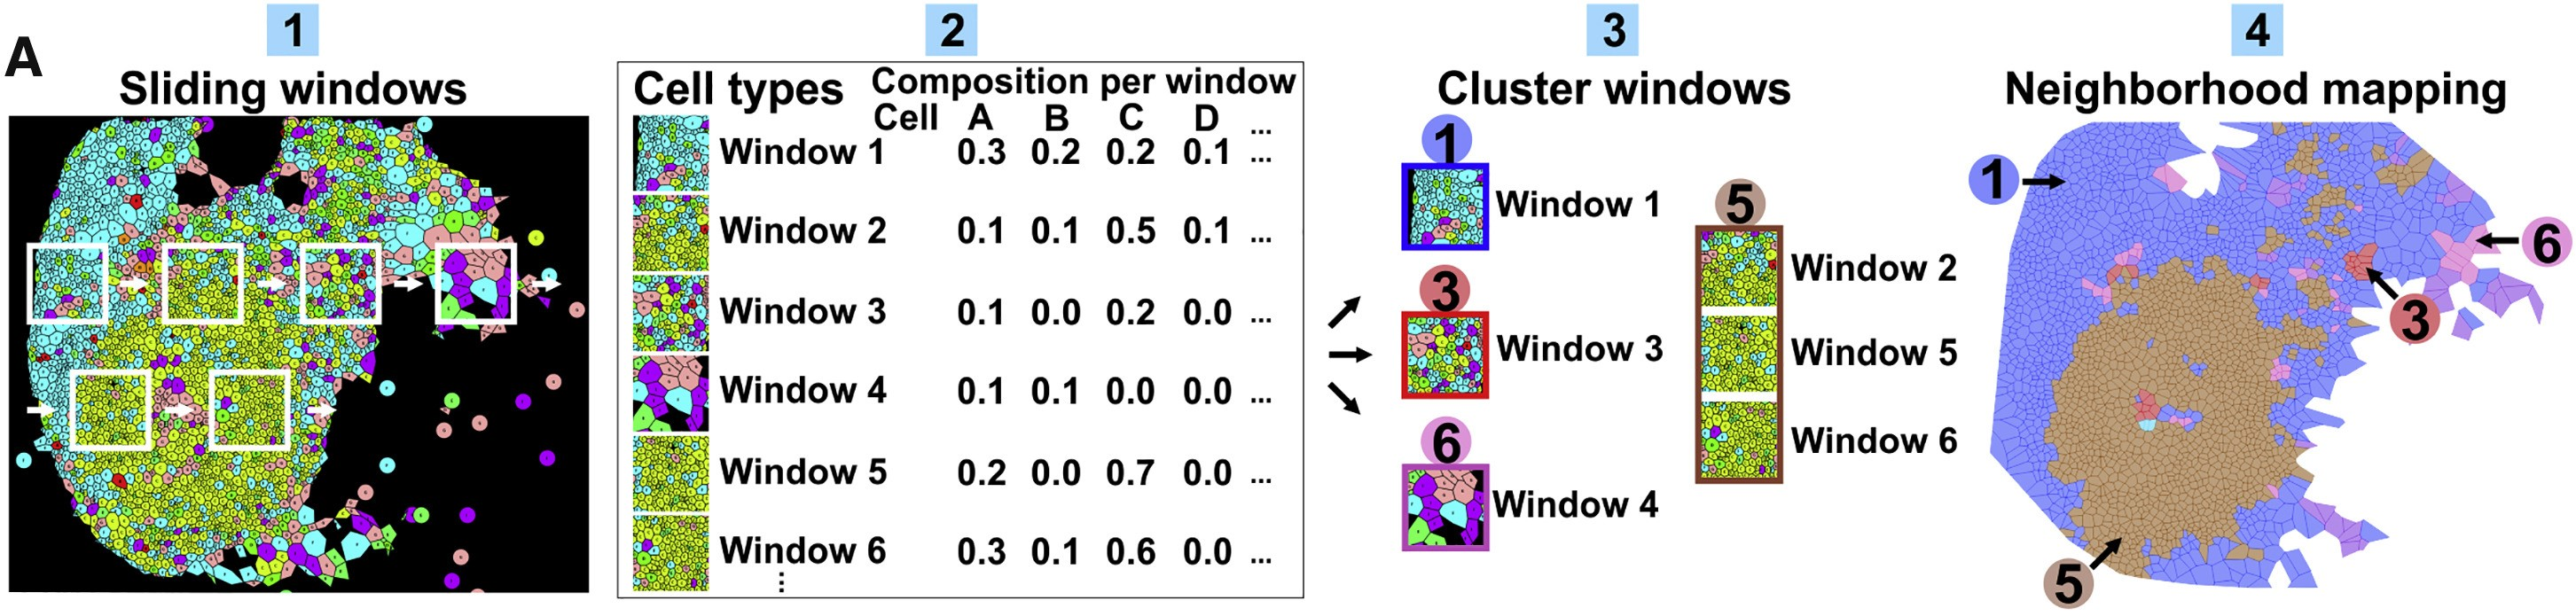

In [3]:
def get_windows(job,n_neighbors):
    start_time,idx,tissue_name,indices = job
    job_start = time.time()

    print ("Starting:", str(idx+1)+'/'+str(len(exps)),': ' + exps[idx])

    tissue = tissue_group.get_group(tissue_name)
    to_fit = tissue.loc[indices][[X,Y]].values

    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X,Y]].values)
    m = fit.kneighbors(to_fit)

    #sort_neighbors
    args = m[0].argsort(axis = 1)
    add = np.arange(m[1].shape[0])*m[1].shape[1]
    sorted_indices = m[1].flatten()[args+add[:,None]]

    neighbors = tissue.index.values[sorted_indices]

    end_time = time.time()

    print ("Finishing:", str(idx+1)+"/"+str(len(exps)),": "+ exps[idx],end_time-job_start,end_time-start_time)
    return neighbors.astype(np.int32)

def get_adata(data, list_keep_obs=None, index_nam = 'tissue_index'):

    if list_keep_obs is None:
        list_keep_obs = ['first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP',
       'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region',
       'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location',
       'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine',
       'MUC6', index_nam]
    data.reset_index(inplace=True)
    data.rename(columns={'index':index_nam}, inplace=True)

    #Prepare for making into anndata format so that obs and data are separate
    data_sc = data.drop(columns = list_keep_obs) #USER INPUT

    #Convert to anndata format
    adata = sc.AnnData(data_sc)
    adata.obs = data[list_keep_obs]
    m_list = adata.var.index.to_list()

    return adata, m_list


def adata_to_dataframe(adata):
    df_var = adata.to_df()
    df_obs = adata.obs
    df = pd.concat([df_var,df_obs], axis=1)
    return df


def sc_heat(data, cell_type, cell_col, vmax=5):
    data_subset = data[data.obs[cell_col] == cell_type]
    sc.pl.heatmap(data_subset, var_names=data.var_names, vmax=vmax, figsize=(20,10), show_gene_labels=True)


def swarm_box(data, grouping, replicate, sub_col, sub_list, per_cat, norm=True,\
              figure_sizing=(10,5), save_name=None, h_order=None):

    plt.style.use(['default'])
    #GENERAL GRAPH SETTINGs
    #font size of graph
    SMALL_SIZE = 14
    MEDIUM_SIZE = 16
    BIGGER_SIZE = 18

    #Settings for graph
    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

    #Find Percentage of cell type
    test= data.copy()
    sub_list1 = sub_list.copy()

    if norm==True:
        test1 = test.loc[test[sub_col].isin(sub_list1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1=test.copy()
        immune_list = list(test.loc[test[sub_col].isin(sub_list1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby([grouping,replicate]).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)
    test_freq.reset_index(inplace=True)
    immune_list.extend([grouping,replicate])
    test_freq1 = test_freq[immune_list]

    melt_per_plot = pd.melt(test_freq1, id_vars=[grouping,replicate,])#,value_vars=immune_list)
    melt_per_plot.rename(columns={'value': 'percentage'}, inplace=True)

    #Order by average
    plot_order = melt_per_plot.groupby(per_cat).mean().reset_index().sort_values(by='percentage')[per_cat].to_list()

    if h_order is None:
        h_order = list(melt_per_plot[grouping].unique())

    #swarmplot to compare clustering
    plt.figure(figsize=figure_sizing)
    ax = sns.boxplot(data = melt_per_plot, x=per_cat,  y='percentage', hue = grouping, dodge=True, order=plot_order,\
                     hue_order=h_order)
    ax = sns.swarmplot(data = melt_per_plot, x=per_cat, y='percentage', hue = grouping, dodge=True, order=plot_order,\
                      hue_order=h_order, edgecolor='black',linewidth=1)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .3))
    #ax.set_yscale(\log\)
    plt.xlabel('')
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:len(melt_per_plot[grouping].unique())], labels[:len(melt_per_plot[grouping].unique())],\
               bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,frameon=False)
    plt.xticks(rotation=90)
    sns.despine(trim=True)
    if save_name:
        plt.savefig(save_path+save_name+'_swarm_boxplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

    return melt_per_plot

def stacked_bar_plot(data, per_cat, grouping, cell_list, norm=True, save_name=None,\
              col_order=None, sub_col=None, name_cat = 'Cell Type',fig_sizing=(8,4), pal_color=None):

    #Find Percentage of cell type
    cell_list_1 = cell_list.copy()
    test= data.copy()
    if norm==True:
        if sub_col is None:
            test1 = test.loc[test[per_cat].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
        else:
            test1 = test.loc[test[sub_col].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
    else:
        if sub_col is None:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[per_cat].isin(cell_list_1)][per_cat].unique())
        else:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    sub_cell_list.append(grouping)
    test_freq = test_freq[sub_cell_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    if norm==True:
        if col_order is None:
            bb = melt_test.groupby([grouping, per_cat]).sum().reset_index()
            col_order = bb.loc[bb[per_cat]==bb[per_cat][0]].sort_values(by='percent')[grouping].to_list()
    else:
        if col_order is None:
            col_order = melt_test.groupby(grouping).sum().reset_index().sort_values(by='percent')[grouping].to_list()

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)

    #Get color dictionary
    if pal_color is None:
        cond_list = list(melt_test_piv.columns)
        color_list=list(pal_temp.values())
        pal_color = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.bar(alpha = 0.8, linewidth=1, color=[pal_color.get(x) for x in melt_test_piv.columns]\
                                  , figsize =fig_sizing, rot=90,stacked=True, edgecolor='black')
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])
    plt.xticks(list(range(len(list(melt_test_piv.index)))), list(melt_test_piv.index), rotation=90)
    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'.png', format='png',\
                    dpi=300, transparent=True, bbox_inches='tight')

def area_plot(data, per_cat, grouping, cell_list, sub_col, color_dict=None, \
              norm=False, save_name=None, col_order=None, name_cat = 'Cell Type',fig_sizing=(8,4)):
    if col_order is None:
        col_order=list(data[grouping].unique())

    cell_list_1 = cell_list.copy()
    #Find Percentage of cell type
    test= data.copy()
    if norm==True:
        test1 = test.loc[test[sub_col].isin(cell_list_1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1 = test.copy()
        immune_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    immune_list.append(grouping)
    test_freq = test_freq[immune_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)
    col_order2 = melt_test_piv.mean().sort_values(ascending=False).index.to_list()
    melt_test_piv= melt_test_piv[col_order2]

    #Get color dictionary
    if color_dict is None:
        cond_list = melt_test_piv.columns.to_list()
        color_list=list(pal_temp.values())
        color_dict = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.area(alpha = 0.8, linewidth=1, color=[color_dict.get(x) for x in melt_test_piv.columns], figsize =fig_sizing, rot=90)
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])

    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    #return melt_test_piv

def percent_plot(cells, per, grouping, x_ax, color_col, save_name, transp = True):

    #dataframe of percentages of interest
    cells[per] = cells[per].astype('category')
    neigh_freqs = cells.groupby(grouping).apply(lambda x: x[per].value_counts(normalize = True,sort = False)*100)

    #transpose or not
    if transp==True:
        per_plot = neigh_freqs.T
    else:
        per_plot = neigh_freqs

    #Order by average
    per_plot_ave = (per_plot.mean(axis=1)).to_frame().reset_index()
    per_plot_ave = per_plot_ave.rename(columns = {0:'percent'})
    per_plot_ave = per_plot_ave.sort_values(by = 'percent')
    per_plot_order = per_plot_ave.set_index(x_ax)
    per_plot_order_t = per_plot_order.T
    col_order_list_1 = per_plot_order_t.columns.to_list()

    #melt the data so that can plot on swarmplot
    per_plot.columns = per_plot.columns.astype(str)
    melt_per_plot = pd.melt(per_plot.reset_index(), id_vars=x_ax, value_vars=per_plot.columns[:])
    melt_per_plot.rename(columns={'value': 'percent'}, inplace=True)

    #swarmplot to compare clustering
    plt.figure(figsize=(20, 5))
    ax1 = sns.swarmplot(data = melt_per_plot, x=x_ax, y = 'percent', hue=color_col, order = col_order_list_1, size=8)
    ax1 = sns.pointplot(x_ax, 'percent',data=melt_per_plot, join=False, ci='sd', color='black', errwidth=1, capsize=.2, order = col_order_list_1)
    plt.xlabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=90)
    plt.savefig(save_path+save_name+'_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    return melt_per_plot

def catplot2(df, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=3, legend=True, palette="bright", figsize=5, style='white', exps=None, axis='on', scatter_kws={}):
    '''
    Plots cells in a tissue section color-coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of points to plot for each cell.
    hue:  color by "Clusterid" or "Node," respectively.
    legend:  include a legend in the plot.
    '''

    # Define default scatterplot keyword arguments
    scatter_kws_ = {'s': size, 'alpha': 1}
    scatter_kws_.update(scatter_kws)

    figures = []  # A list to store plot figures
    df = df.rename(columns=lambda x: str(x))  # Rename DataFrame columns

    # Ensure the 'hue' column is treated as a categorical variable
    df[hue] = df[hue].astype("category")

    if invert_y:
        # If 'invert_y' is True, invert the Y-values
        y_orig = df[Y].values.copy()
        df[Y] *= -1

    style = {'axes.facecolor': style}
    sns.set_style(style)

    if exps is None:
        exps = list(df[exp].unique())  # Display all experiments if 'exps' is not specified
    elif not isinstance(exps, list):
        exps = [exps]  # Ensure 'exps' is a list

    for name in exps:
        data = df[df[exp] == name]  # Filter data for the specified experiment

        print(name)  # Print the name of the current experiment

        # Create a scatterplot (lmplot) using Seaborn
        f = sns.lmplot(x=X, y=Y, data=data, hue=hue,
                       legend=legend, fit_reg=False, markers='.', height=figsize, palette=palette, scatter=True, scatter_kws=scatter_kws_)

        if axis == 'off':
            # If 'axis' is 'off', remove axis lines and labels
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)  # Set the title of the plot

        plt.show()  # Display the plot
        figures += [f]  # Add the plot figure to the list

    if invert_y:
        df[Y] = y_orig  # Restore the original Y-values if 'invert_y' was used

    return figures


##### Processing code:

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
file_type = 'csv'

cellhier_path = '/Users/jodie/OneDrive/Documents/Python Scripts/Hierarchical-Tissue-Unit-Annotation'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

cluster_col = 'Neighborhood'
keep_cols = [X,Y,reg,cluster_col]
save_path = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/panorgan'

In [5]:
#Import Data
n_neighbors = max(ks)
sys.path.append(cellhier_path)
from cellhier.general import *

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col])],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [6]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

Starting: 1/66 : B004_Ascending
Finishing: 1/66 : B004_Ascending 1.162123680114746 1.1625115871429443
Starting: 9/66 : B004_Descending
Finishing: 9/66 : B004_Descending 1.6833243370056152 2.8771073818206787
Starting: 51/66 : B004_Descending - Sigmoid
Finishing: 51/66 : B004_Descending - Sigmoid 1.259451150894165 4.174181938171387
Starting: 18/66 : B004_Duodenum
Finishing: 18/66 : B004_Duodenum 2.3603293895721436 6.558401584625244
Starting: 25/66 : B004_Ileum
Finishing: 25/66 : B004_Ileum 1.4074938297271729 8.026159048080444
Starting: 34/66 : B004_Mid-jejunum
Finishing: 34/66 : B004_Mid-jejunum 1.886021614074707 9.943444013595581
Starting: 42/66 : B004_Proximal Jejunum
Finishing: 42/66 : B004_Proximal Jejunum 1.524916172027588 11.515337705612183
Starting: 59/66 : B004_Transverse
Finishing: 59/66 : B004_Transverse 1.8995890617370605 13.446176290512085
Starting: 2/66 : B005_Ascending
Finishing: 2/66 : B005_Ascending 0.9031047821044922 14.380707740783691
Starting: 10/66 : B005_Descending
F

In [7]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

#### Neighborhood Analysis

In [17]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells[cluster_col]

In [18]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 15

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

In [19]:
# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2[sum_cols].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells[neighborhood_name] = labels

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


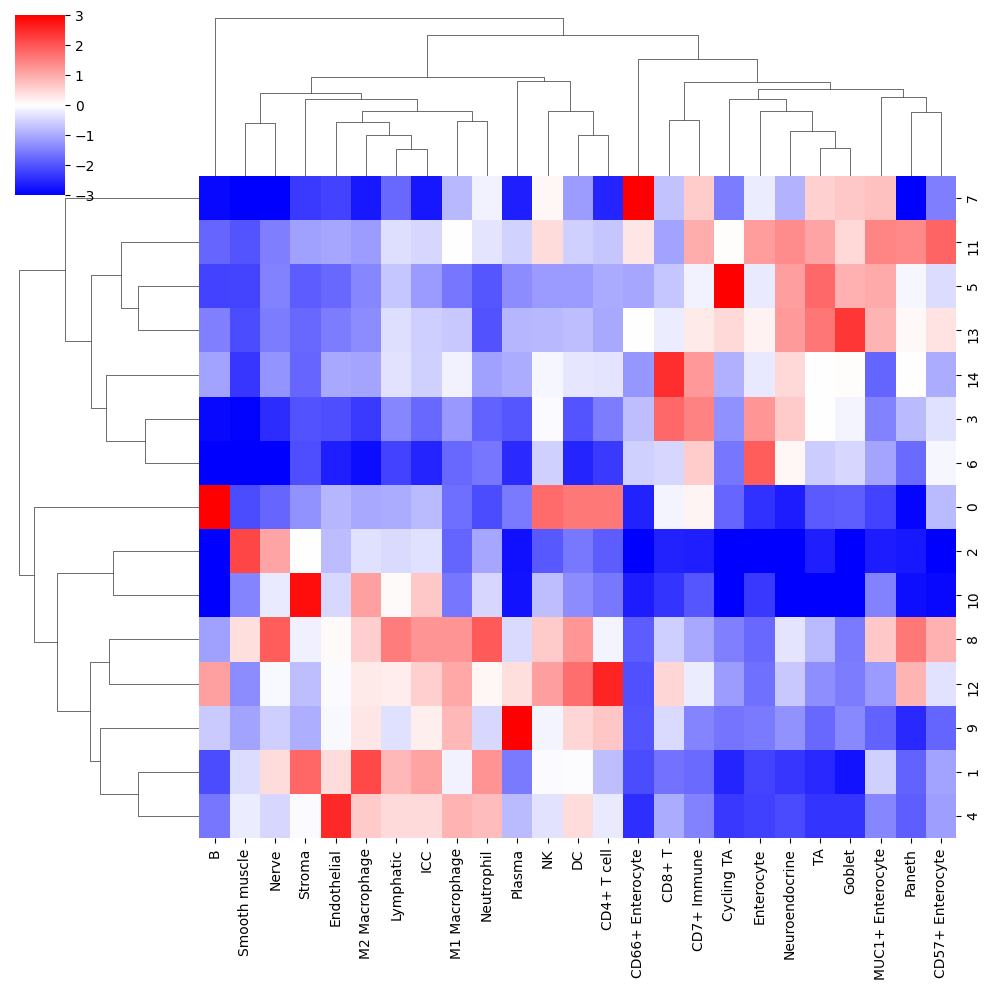

In [20]:
# Select the centroids for a specific value of 'k' for plotting
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])

# Calculate the average cell types across the 'values' array
tissue_avgs = values.mean(axis=0)

# Compute fold change (fc) of cell types abundance within a neighborhood versus that in the tissue
# This involves a log2 transformation of the ratio of (niche_clusters + tissue_avgs) to tissue_avgs
# The ratio is normalized by the sum across each row (axis=1), ensuring that the sum of ratios for each row is 1
fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc = pd.DataFrame(fc, columns=sum_cols)

# Create a clustered heatmap using seaborn's clustermap function
# 'fc' DataFrame is used as input
# vmin and vmax set the color scale limits for the heatmap (-3 to 3 in this case)
# cmap='bwr' sets the color palette to blue-white-red
# figsize=(10,10) sets the size of the heatmap
s = sns.clustermap(fc, vmin=-3, vmax=3, cmap='bwr', figsize=(10,10))

In [ ]:
#Use the function to plot the cell neighborhoods back to the tissue coordinates for additional
  #insight to what is

#Just using one donors values for now because of the amount of time to plot all
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['donor']=='B008']
figs = catplot2(sub_cells, X = 'x', Y='y', exp = 'unique_region',
               hue = neighborhood_name, invert_y=True, size = 2, figsize=8)

#### Single Cell Type Focused

Looking at different nearest number of cells $k$ around paneth cells and use K means clustering to them as 1 neighborhood. By comparing the composition of each neighborhood with different $k$ values we can see the different tissue structures impacted by distances around paneth cells.

In [8]:
cells.columns

Index(['Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f',
       'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR',
       'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90',
       'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34',
       'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117',
       'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163',
       'CD161', 'x', 'y', 'array', 'Xcorr', 'Ycorr', 'Tissue_location',
       'tissue', 'donor', 'unique_region', 'region', 'OLFM4', 'FAP', 'CD25',
       'CollIV', 'CK7', 'MUC6', 'Cell Type', 'Cell Type em', 'Cell subtype',
       'Neighborhood', 'Neigh_sub', 'Neighborhood_Ind', 'NeighInd_sub',
       'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit',
       'Adatpive Immune Enriched', 'CD66+ Mature Epithelial',
       'CD8+ T Enriched IEL', 'Glandular Epithelial', 'Innate Immune Enriched',
       'Inner Follicle', 'Innerva

In [11]:
#Fill in based on above
k = 10
n_neighborhoods = 15
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
cluster_col1 = 'Cell Type'
celltype_windows = windows2[windows2[cluster_col1].isin(cell_list)]
type_cells = cells[cells[cluster_col1].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
fc_output

KeyError: 'Cell Type'

In [ ]:
#modify figure size aesthetics for each neighborhood
plt.rcParams["legend.markerscale"] = 3
figs = catplot2(type_cells,X = 'x',Y='y', exp= reg,
               hue = 'Cell Type em',invert_y=False,size = 1,figsize=8, exps=None, axis='on', scatter_kws={})

In [1]:
# #this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
# k_to_plot = k
# niche_clusters = (k_centroids[k_to_plot])
# tissue_avgs = values.mean(axis = 0)
# fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
# fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_output, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,10))
s.fig.suptitle('Endothelial Community Analysis, Log Fold Change')
s.fig.text(x=0.47, y=0.93, s = 'k=10')

NameError: name 'sns' is not defined

#### UMAP visualization - cell type

In [26]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)

<ipython-input-26-05faebae2e23>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)


In [27]:
markerlist = [
 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
       'Tissue_location', 'array', 'Cell Type', 'Cell subtype',
       'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
       'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment',
]

In [28]:
#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))
#markerlist.append('day harvested')

marker_df = type_cells[markerlist]


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T
#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()
#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])

marker_df.columns

<ipython-input-28-9c1c4f6bee0c>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
<ipython-input-28-9c1c4f6bee0c>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
<ipython-input-28-9c1c4f6bee0c>:14: SettingWithCopyWarning: 
A value is trying to be set on a co

Index(['tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location',
       'array', 'Cell Type', 'Cell subtype', 'Neighborhood',
       'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community',
       'Major Community', 'Tissue Segment', 'neighborhood50', 'Enriched NK',
       'Enriched Enterocyte', 'Enriched MUC1+ Enterocyte', 'Enriched TA',
       'Enriched CD66+ Enterocyte', 'Enriched Paneth',
       'Enriched Smooth muscle', 'Enriched M1 Macrophage', 'Enriched Goblet',
       'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte',
       'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched DC',
       'Enriched M2 Macrophage', 'Enriched B', 'Enriched Neutrophil',
       'Enriched Endothelial', 'Enriched Cycling TA', 'Enriched Plasma',
       'Enriched CD4+ T cell', 'Enriched Stroma', 'Enriched Nerve',
       'Enriched ICC', 'Enriched CD7+ Immune'],
      dtype='object')

In [29]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)
comb_df

,x,y,unique_region,Cell Type,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,...,Enriched B,Enriched Neutrophil,Enriched Endothelial,Enriched Cycling TA,Enriched Plasma,Enriched CD4+ T cell,Enriched Stroma,Enriched Nerve,Enriched ICC,Enriched CD7+ Immune
36246,134.0,295.0,B004_Ascending,CD8+ T,0.0,15.0,0.0,0.0,3.0,0.0,...,-2.103341,-1.231168,-0.579225,-0.578238,1.962776,0.370667,-1.313178,-1.224647,-0.211948,-0.843910
36247,278.0,155.0,B004_Ascending,CD8+ T,0.0,20.0,1.0,2.0,1.0,0.0,...,-3.877076,-1.155124,-1.113818,-0.672521,-0.913424,-1.078123,-1.742556,-2.421299,-1.681265,1.433705
36248,449.0,448.0,B004_Ascending,CD8+ T,0.0,8.0,1.0,2.0,2.0,0.0,...,-0.863340,-0.203419,0.084235,-0.434204,2.482727,0.883045,-1.443749,-0.546670,0.419984,-1.204019
36249,482.0,49.0,B004_Ascending,CD8+ T,0.0,24.0,3.0,0.0,1.0,0.0,...,-3.877076,-1.155124,-1.113818,-0.672521,-0.913424,-1.078123,-1.742556,-2.421299,-1.681265,1.433705
36250,496.0,562.0,B004_Ascending,CD8+ T,0.0,8.0,0.0,3.0,3.0,0.0,...,-0.863340,-0.203419,0.084235,-0.434204,2.482727,0.883045,-1.443749,-0.546670,0.419984,-1.204019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2593427,1205.0,5978.0,B008_Trans,CD8+ T,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.863340,-0.203419,0.084235,-0.434204,2.482727,0.883045,-1.443749,-0.546670,0.419984,-1.204019
2593428,4562.0,4453.0,B008_Trans,CD8+ T,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.640996,0.995521,0.854237,-3.963974,-2.096352,-0.067334,2.047582,-0.168506,1.210277,-1.188607
2593429,1630.0,7089.0,B008_Trans,CD8+ T,0.0,9.0,0.0,0.0,1.0,0.0,...,-1.562656,0.055988,0.476827,-0.889095,-0.467207,0.201042,-1.266605,-0.895923,-0.029250,0.250966
2593430,7402.0,177.0,B008_Trans,CD8+ T,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.393834,0.359043,0.048264,-1.839424,-2.121757,0.141355,0.161485,0.855919,0.360432,-1.779135


In [30]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)
df['neighborhood'+str(k)]

36246       4
36247       2
36248      17
36249       2
36250      17
           ..
2593427    17
2593428     8
2593429    15
2593430     9
2593431    15
Name: neighborhood50, Length: 214465, dtype: object

In [31]:
df.columns

Index(['x', 'y', 'unique_region', 'Cell Type', 'NK', 'Enterocyte',
       'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte', 'Paneth', 'Smooth muscle',
       'M1 Macrophage', 'Goblet', 'Neuroendocrine', 'CD57+ Enterocyte',
       'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B', 'Neutrophil',
       'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell', 'Stroma', 'Nerve',
       'ICC', 'CD7+ Immune', 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
       'Tissue_location', 'array', 'Cell Type', 'Cell subtype', 'Neighborhood',
       'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community',
       'Major Community', 'Tissue Segment', 'neighborhood50', 'Enriched NK',
       'Enriched Enterocyte', 'Enriched MUC1+ Enterocyte', 'Enriched TA',
       'Enriched CD66+ Enterocyte', 'Enriched Paneth',
       'Enriched Smooth muscle', 'Enriched M1 Macrophage', 'Enriched Goblet',
       'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte',
       'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched

In [32]:
cell_enr = [
 'Enriched NK', 'Enriched Enterocyte',
       'Enriched CD66+ Enterocyte', 'Enriched TA',
       'Enriched MUC1+ Enterocyte',
       'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage',
       'Enriched Goblet', 'Enriched Neuroendocrine',
       'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T',
       'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B',
       'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA',
       'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma',
       'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune',
]


collist = [
'x', 'y', 'unique_region', 'Cell Type','tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community',
       'Tissue Segment'
 ]

#Prepare for making into anndata format so that obs and data are separate
windows_list = [
 'NK', 'Enterocyte',
       'CD66+ Enterocyte', 'TA', 'MUC1+ Enterocyte',
       'Smooth muscle', 'Paneth', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune']

In [33]:
df1 = df.drop(columns = collist ) #USER INPUT
df1.columns

Index(['NK', 'Enterocyte', 'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte',
       'Paneth', 'Smooth muscle', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune', 'neighborhood50',
       'Enriched NK', 'Enriched Enterocyte', 'Enriched MUC1+ Enterocyte',
       'Enriched TA', 'Enriched CD66+ Enterocyte', 'Enriched Paneth',
       'Enriched Smooth muscle', 'Enriched M1 Macrophage', 'Enriched Goblet',
       'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte',
       'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched DC',
       'Enriched M2 Macrophage', 'Enriched B', 'Enriched Neutrophil',
       'Enriched Endothelial', 'Enriched Cycling TA', 'Enriched Plasma',
       'Enriched CD4+ T cell', 'Enriched Stroma', 'Enriched Nerve',
       'Enriched ICC', 'Enriched CD7+ Immune'],
      dtype='object')

In [34]:
#Prepare for making into anndata format
dfw = df1[windows_list]
dfw.columns

Index(['NK', 'Enterocyte', 'CD66+ Enterocyte', 'TA', 'MUC1+ Enterocyte',
       'Smooth muscle', 'Paneth', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune'],
      dtype='object')

In [35]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]
adata_w

/usr/local/lib/python3.10/dist-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [36246, 36247, 36248, 36249, 36250]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 214465 × 25
    obs: 'x', 'y', 'unique_region', 'Cell Type', 'Cell Type', 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell subtype', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Enriched NK', 'Enriched Enterocyte', 'Enriched CD66+ Enterocyte', 'Enriched TA', 'Enriched MUC1+ Enterocyte', 'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage', 'Enriched Goblet', 'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B', 'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA', 'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma', 'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune'

In [36]:
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1

/usr/local/lib/python3.10/dist-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packa

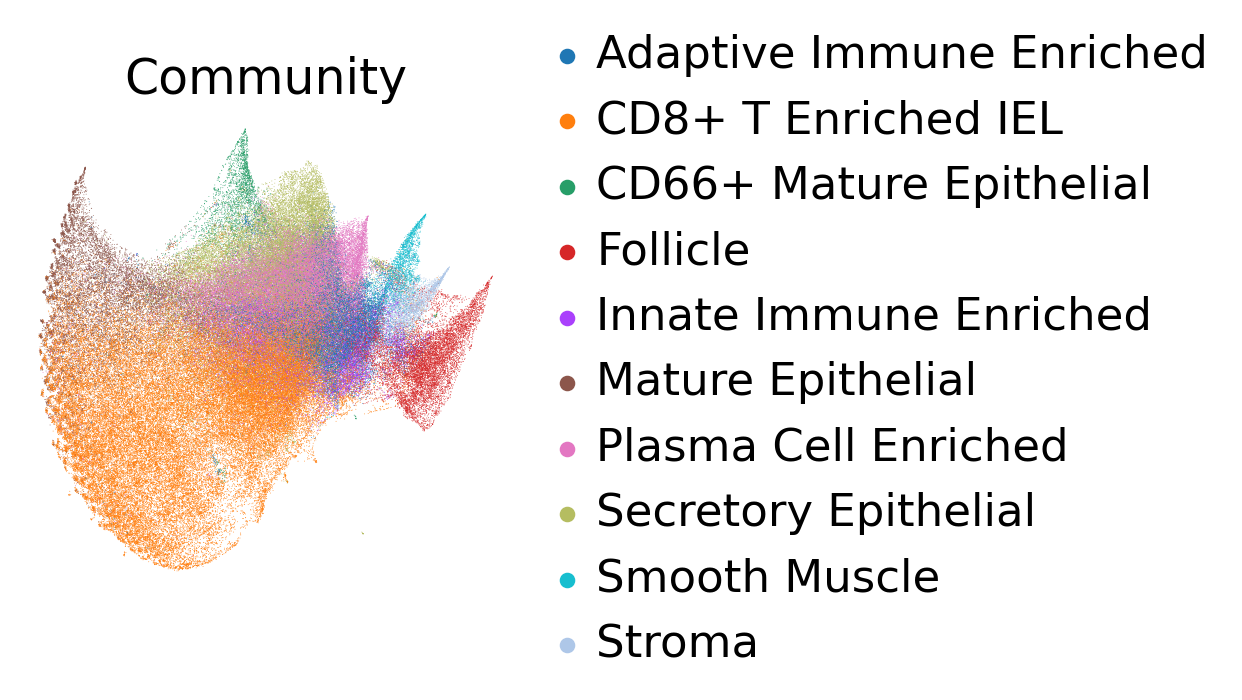

In [37]:
#Compute the neighborhood relations of single cells.
#The size of local neighborhood (in terms of number of neighboring data points) used for
#manifold approximation. Larger values result in more global views of the manifold, while
#smaller values result in more local data being preserved. In general values should be in
#the range 2 to 100 and a good average is 10
#13 is good
sc.pp.neighbors(adata_w, n_neighbors=20)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='Community',)

/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c


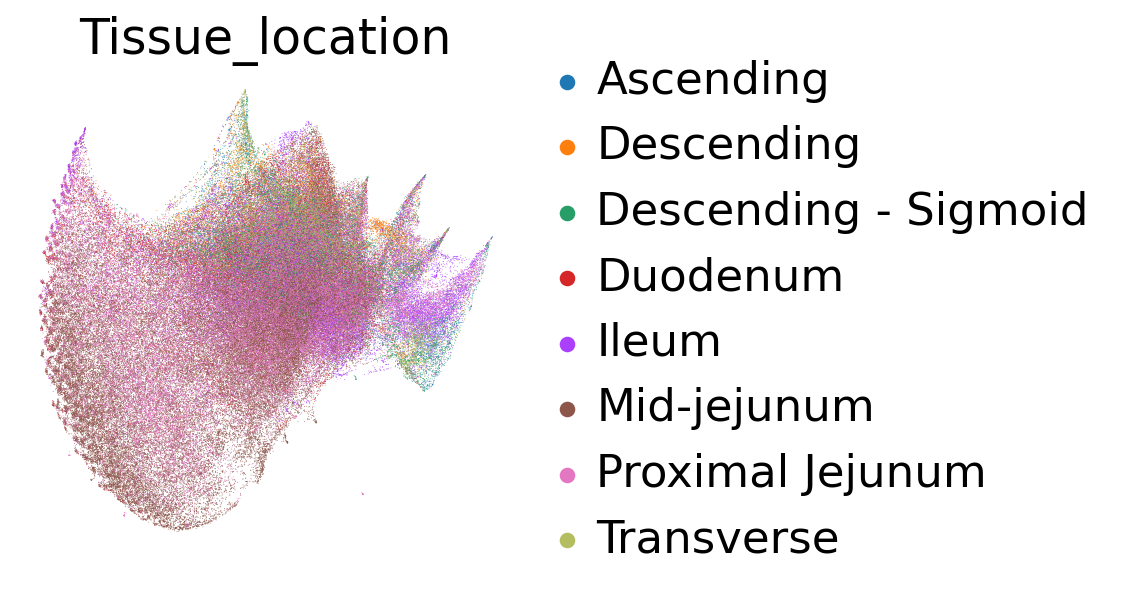

In [ ]:
sc.pl.umap(adata_w, color ='Tissue_location',)

In [ ]:
!pip3 install leidenalg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.4 MB/s eta 0:00:00


<ipython-input-29-dcf715d7ff7d>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_w, resolution=0.5)
/usr/local/lib/python3.10/dist-packages/scanpy/tools/_leiden.py:197: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs[key_added] = pd.Categorical(
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

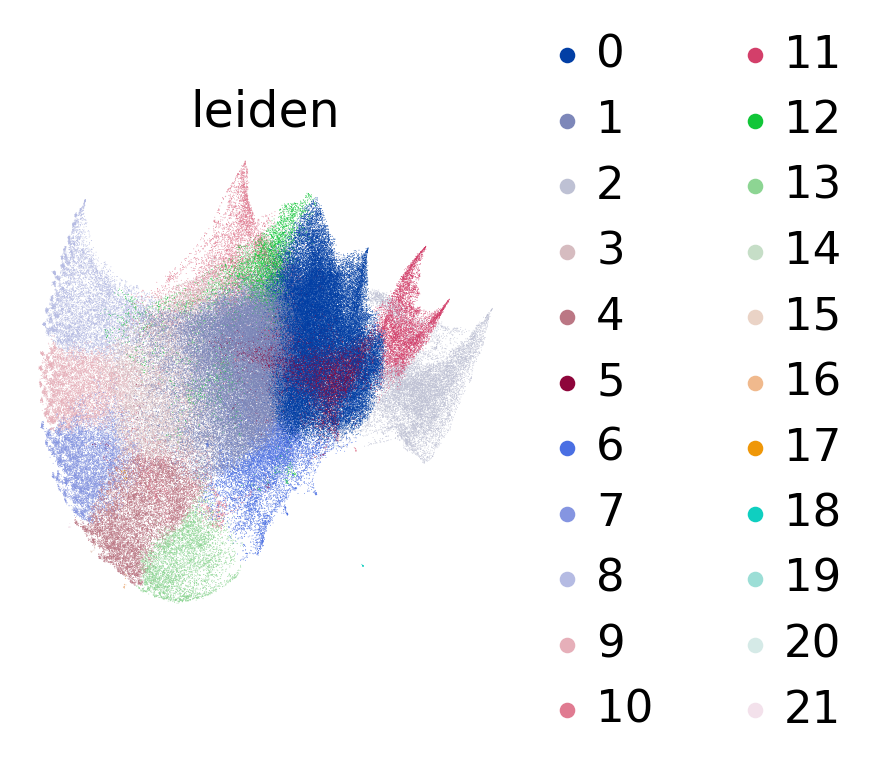

In [ ]:
sc.tl.leiden(adata_w, resolution=0.5)
sc.pl.umap(adata_w, color ='leiden')

#### Rings Analysis

Filter windows to only contain 1 cell type and perform neighborhood analysis to get 1 cluster for each $k$.

In [38]:
#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]

#Only use T cell windows for example in cell_list
cell_name = 'stem cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['CD8+ T']
celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
type_cells = cells[cells[cluster_col].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
fc_output

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-38-c9161d719f5d>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells[neighborhood_name] = labels


,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,Smooth muscle,M1 Macrophage,Goblet,Neuroendocrine,...,B,Neutrophil,Endothelial,Cycling TA,Plasma,CD4+ T cell,Stroma,Nerve,ICC,CD7+ Immune
50,0.313406,0.479071,-1.098528,-0.017522,-0.426094,0.098228,-1.685738,0.115859,0.170877,0.321556,...,0.13512,-0.766085,-0.410541,-0.328413,-0.0131,0.313509,-1.417217,-1.131606,-0.432844,0.876488


In [40]:
def fc_out(data, k_num):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]

    #Only use T cell windows for example in cell_list
    cell_name = 'stem data'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['CD8+ T']
    celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
    type_data = data[data[cluster_col].isin(cell_list)]

    #Add lables
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

In [41]:
fc_list = []
niche_list = []
for kn in ks:
    df1, df2 = fc_out(data=cells, k_num=kn)
    fc_list.append(df1)
    niche_list.append(df2)

fc_comb = pd.concat(fc_list)
niche_comb=pd.concat(niche_list)
niche_comb

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-40-fa62a62ba317>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data[neighborhood_name] = labels
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-40-fa62a62ba317>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,Smooth muscle,M1 Macrophage,Goblet,Neuroendocrine,...,B,Neutrophil,Endothelial,Cycling TA,Plasma,CD4+ T cell,Stroma,Nerve,ICC,CD7+ Immune
5,0.171274,20.859375,0.189303,1.606070,0.859375,0.516827,2.417368,0.677584,5.444712,0.563401,...,1.248498,0.214844,3.064904,1.777344,3.440505,5.036058,2.396334,1.063702,0.700120,0.497296
10,0.198568,24.484863,0.240885,1.854655,1.023763,0.658366,3.120931,0.789388,6.446940,0.661621,...,1.394857,0.247396,3.907064,2.084147,4.174805,5.560710,2.732747,1.246745,0.901693,0.525716
30,0.236816,26.977539,0.298937,2.094727,1.299913,0.852322,4.018826,0.907932,7.076552,0.747070,...,1.474609,0.306532,5.064562,2.396105,4.807400,5.851780,3.018663,1.351183,0.961914,0.567220
50,0.263997,27.587891,0.318197,2.192383,1.437337,0.930013,4.389160,0.942871,7.210449,0.748210,...,1.501790,0.332845,5.380859,2.542643,5.048828,5.765137,3.071289,1.353678,0.987305,0.544922
100,0.284587,28.230143,0.343750,2.322021,1.571940,1.001872,4.702148,0.953695,7.405843,0.757568,...,1.518229,0.336833,5.559082,2.722168,5.209880,5.677246,3.084310,1.343180,1.009684,0.534912
300,0.305366,28.478299,0.365153,2.420573,1.606527,0.993001,5.077691,0.949599,7.530518,0.764025,...,1.543538,0.322293,5.683133,2.910129,5.450250,5.628852,3.152832,1.363580,1.020372,0.519287


In [42]:
plt.style.use(['default'])
#GENERAL GRAPH SETTINGs
#font size of graph
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

#Settings for graph
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

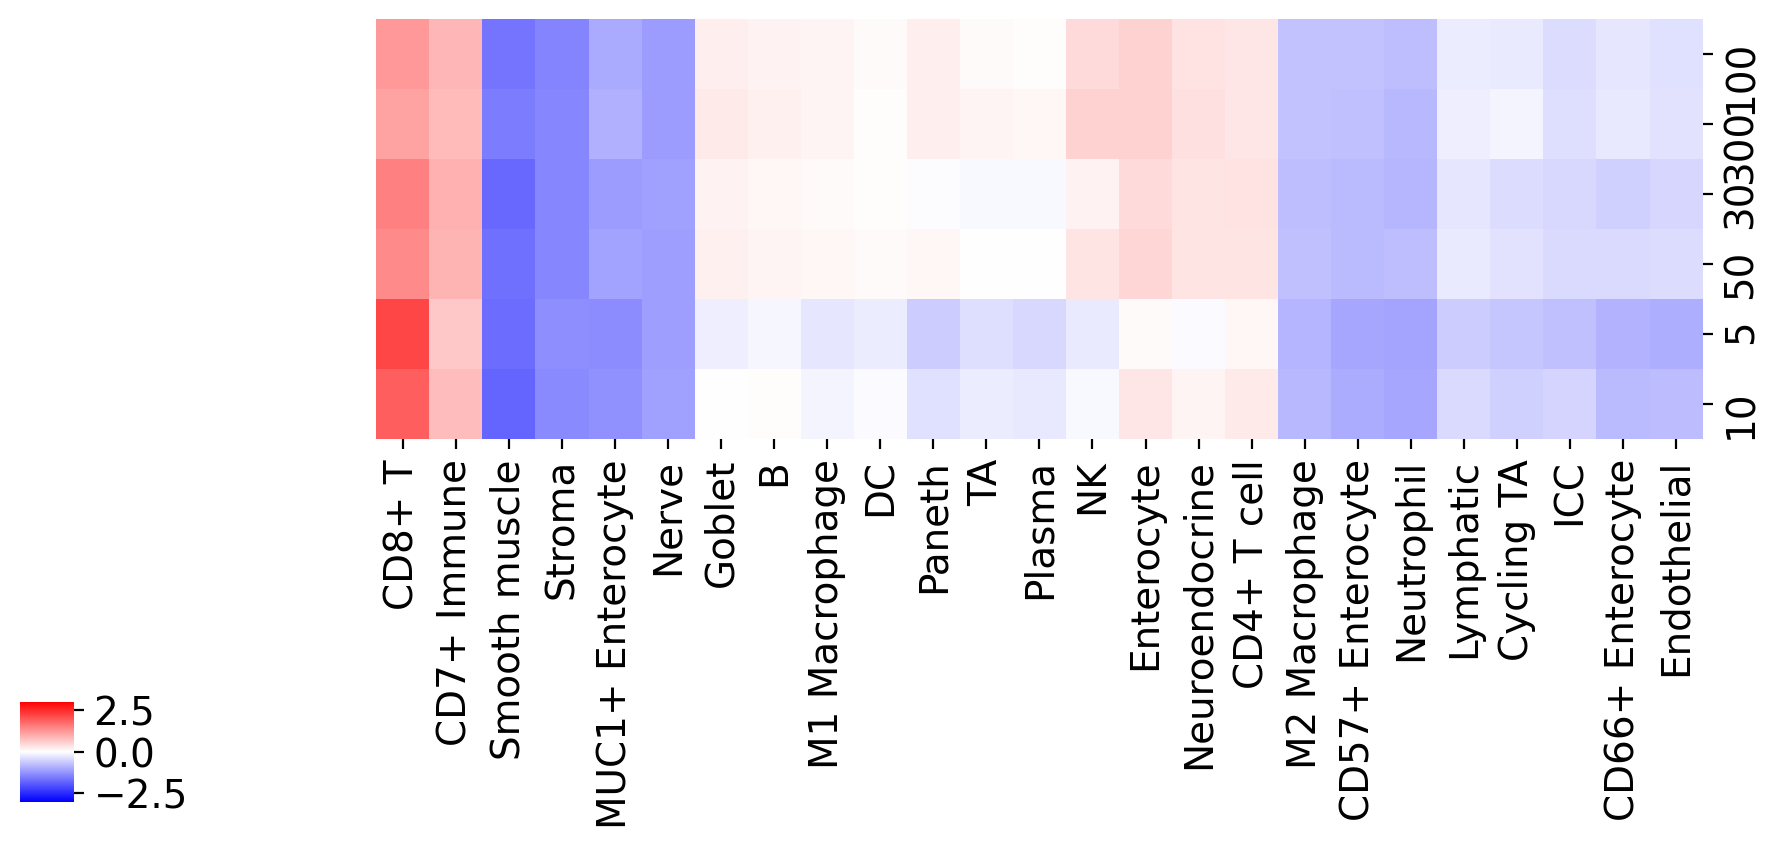

In [44]:
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(9,5),cbar_pos=(0.01,0.07,0.03,0.1))
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#s.ax_heatmap.set_ylabel("", labelpad=25)
#s.ax_heatmap.tick_params(axis='y', pad=15)
#s.ax_heatmap.yaxis.set_ticks_position("left")

plt.savefig(save_path+'CD8+T_cell_enrichment.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

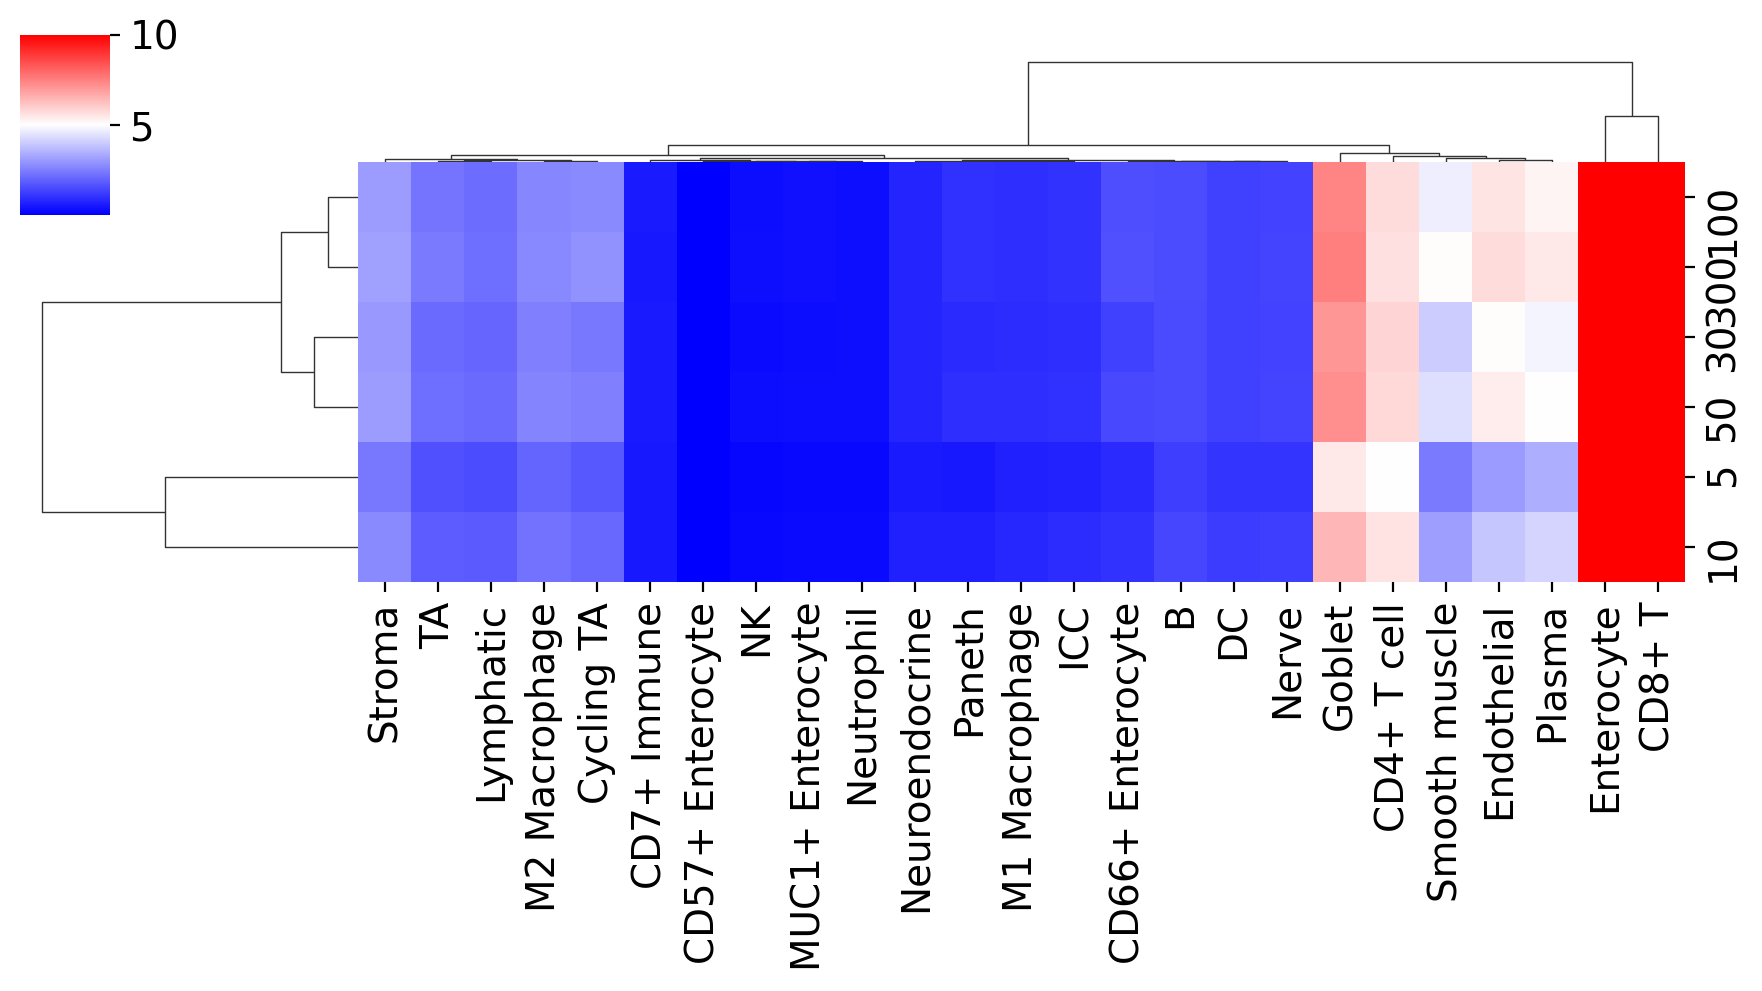

In [45]:
s=sns.clustermap(niche_comb, vmax=10, cmap = 'bwr', figsize=(9,5))
plt.savefig(save_path+'CD8+T_cell_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [46]:
cell_map = {
    'NK': 'blue',
 'Enterocyte': 'magenta',
 'MUC1+ Enterocyte': 'yellow',
 'TA': 'skyblue',
 'CD66+ Enterocyte': 'darkorange',
 'Paneth': 'green',
 'Smooth muscle': 'red',
 'Cycling TA': 'tan',
 'M1 Macrophage': 'gray',
 'Goblet': 'indigo',
 'Neuroendocrine': 'yellowgreen',
 'CD57+ Enterocyte': 'lightsalmon',
 'Lymphatic': 'plum',
 'CD8+ T': 'gold',
 'DC': 'blueviolet',
 'M2 Macrophage': 'bisque',
 'B': 'navy',
 'Neutrophil': 'goldenrod',
 'Endothelial': 'black',
 'Plasma': 'yellow',
 'CD4+ T cell': 'brown',
 'Stroma': 'dimgray',
 'Nerve': 'olive',
 'ICC': 'teal',
 'CD7+ Immune': 'lightcoral'}

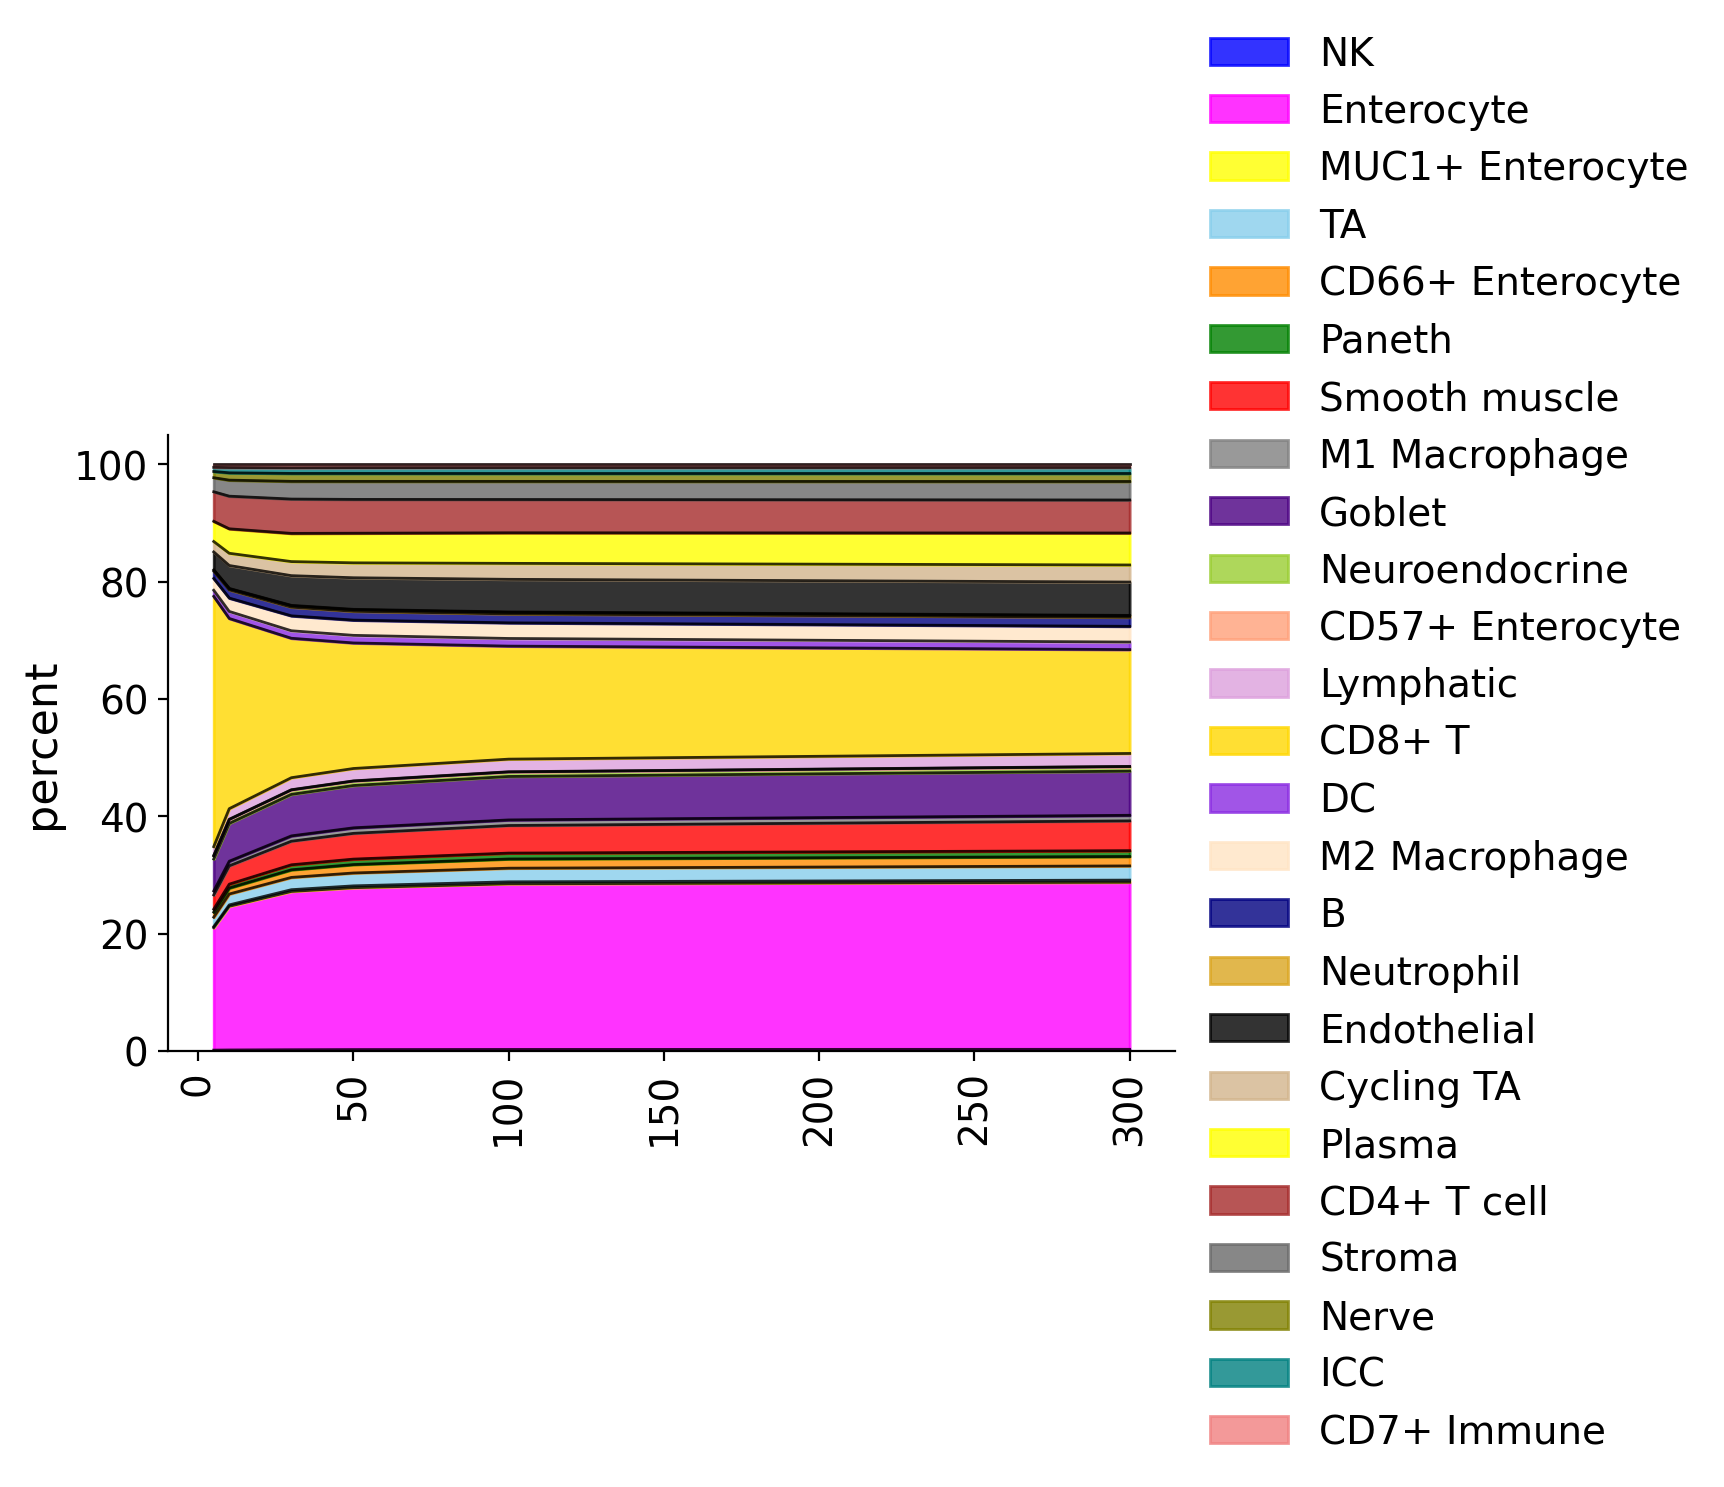

In [47]:
#first subplot
ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, color=[cell_map.get(x) for x in niche_comb.columns],\
                           figsize =(6.5,4), rot=90)
for line in ax1.lines:
    line.set_color('black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('percent')

lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)

#plt.savefig(save_path+'Panethcell_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

#### Neighborhood Focused

In [5]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = "/content/drive/MyDrive/panorgan/23_09_CODEX_HuBMAP_alldata_Dryad_merged copy.csv"

X = 'x'
Y = 'y'
reg = 'unique_region'
cluster_col = 'Neighborhood'

cellhier_path = '/content/drive/MyDrive/panorgan/cellhier'
keep_cols = [X,Y,reg,cluster_col,'Cell Type']
save_path = '/content/drive/MyDrive/panorgan'

In [6]:
#Import Data
n_neighbors = max(ks)
sys.path.append(cellhier_path)
from cellhier.general import *

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col])],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [7]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

Starting: 1/66 : B004_Ascending
Finishing: 1/66 : B004_Ascending 1.571033000946045 1.5785281658172607
Starting: 9/66 : B004_Descending
Finishing: 9/66 : B004_Descending 2.0325872898101807 3.6283419132232666
Starting: 51/66 : B004_Descending - Sigmoid
Finishing: 51/66 : B004_Descending - Sigmoid 2.0729949474334717 5.715779066085815
Starting: 18/66 : B004_Duodenum
Finishing: 18/66 : B004_Duodenum 3.769256591796875 9.500102758407593
Starting: 25/66 : B004_Ileum
Finishing: 25/66 : B004_Ileum 2.393904209136963 11.92559027671814
Starting: 34/66 : B004_Mid-jejunum
Finishing: 34/66 : B004_Mid-jejunum 2.3923399448394775 14.32960295677185
Starting: 42/66 : B004_Proximal Jejunum
Finishing: 42/66 : B004_Proximal Jejunum 2.0287668704986572 16.373013973236084
Starting: 59/66 : B004_Transverse
Finishing: 59/66 : B004_Transverse 2.1809093952178955 18.572024822235107
Starting: 2/66 : B005_Ascending
Finishing: 2/66 : B005_Ascending 1.2341961860656738 19.822385549545288
Starting: 10/66 : B005_Descending


In [8]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

In [9]:
#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]

#Only use T cell windows for example in cell_list
cell_name = 'stem cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['CD8+ T']
celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
type_cells = cells[cells['Cell Type'].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
fc_output

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-9-5f22f5290097>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells[neighborhood_name] = labels


,Mature Epithelial,Transit Amplifying Zone,Innate Immune Enriched,Stroma & Innate Immune,Outer Follicle,Adatpive Immune Enriched,Secretory Epithelial,CD66+ Mature Epithelial,Plasma Cell Enriched,Innervated Stroma,Smooth Muscle & Innate Immune,Microvasculature,Innervated Smooth Muscle,Inner Follicle,Macrovasculature,Stroma,Glandular Epithelial,CD8+ T Enriched IEL,Smooth Muscle,Paneth Enriched
50,0.476923,-0.453021,-0.225041,-1.40046,0.422771,0.969533,0.313981,-0.714154,-0.089319,-1.977673,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652


In [10]:
def fc_out(data, k_num):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]

    #Only use T cell windows for example in cell_list
    cell_name = 'stem data'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['CD8+ T']
    celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
    type_data = data[data['Cell Type'].isin(cell_list)]

    #Add lables
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

In [11]:
fc_list = []
niche_list = []
for kn in ks:
    df1, df2 = fc_out(data=cells, k_num=kn)
    fc_list.append(df1)
    niche_list.append(df2)

fc_comb = pd.concat(fc_list)
niche_comb=pd.concat(niche_list)
niche_comb

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-10-c3bd3e44351b>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data[neighborhood_name] = labels
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-10-c3bd3e44351b>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

,Mature Epithelial,Transit Amplifying Zone,Innate Immune Enriched,Stroma & Innate Immune,Outer Follicle,Adatpive Immune Enriched,Secretory Epithelial,CD66+ Mature Epithelial,Plasma Cell Enriched,Innervated Stroma,Smooth Muscle & Innate Immune,Microvasculature,Innervated Smooth Muscle,Inner Follicle,Macrovasculature,Stroma,Glandular Epithelial,CD8+ T Enriched IEL,Smooth Muscle,Paneth Enriched
5,8.390625,4.712240,1.537760,0.550781,4.174479,12.130208,14.243490,1.031250,7.265625,0.210937,1.188802,1.750000,0.332031,1.376302,0.553385,1.076823,0.143229,38.246094,0.231771,0.854167
10,9.583834,5.337290,1.819411,0.553636,4.408053,11.561749,13.925781,1.109525,7.684044,0.226863,1.316857,2.024489,0.348558,1.416016,0.649038,0.992338,0.153245,35.588942,0.356070,0.944261
30,12.381185,7.559408,2.549642,0.698513,4.880914,8.908420,13.790419,1.245117,9.747179,0.309516,1.576877,2.829047,0.425076,1.548123,0.992025,1.079102,0.184462,27.511393,0.630968,1.152615
50,13.166667,8.375000,2.775228,0.764811,4.916829,8.058919,13.733236,1.322754,10.406413,0.325846,1.681315,3.118001,0.463216,1.588542,1.174967,1.085775,0.192057,24.833659,0.762207,1.254557
100,14.046549,9.271159,2.907145,0.798421,4.846354,7.290527,13.743408,1.401123,10.917806,0.337891,1.790690,3.363444,0.493408,1.604411,1.308838,1.092367,0.189616,22.315511,0.919840,1.361491
300,14.526584,10.097928,2.965088,0.798557,4.733371,6.684814,13.790826,1.413005,11.533908,0.348090,1.908773,3.435221,0.562012,1.668566,1.377279,1.114638,0.194933,20.361789,1.126302,1.358317


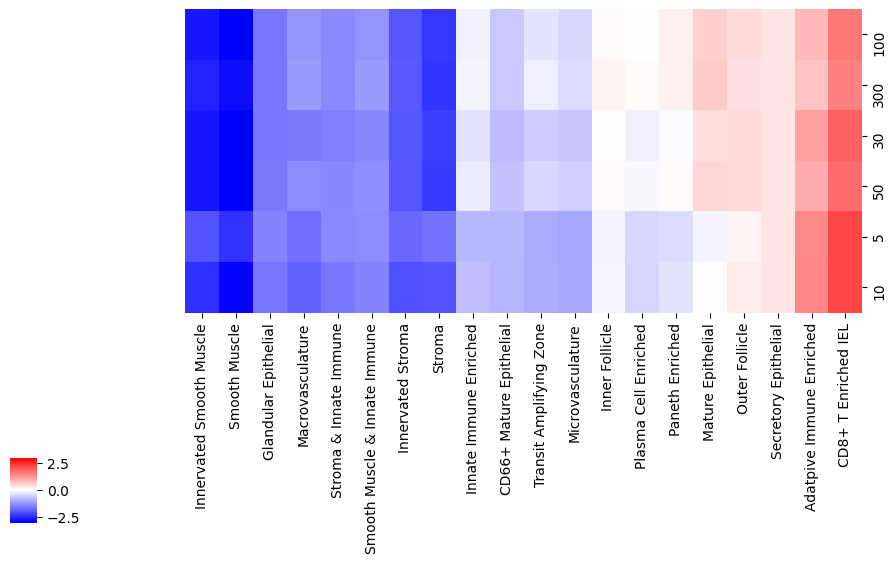

In [12]:
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(9,6.5),cbar_pos=(0.01,0.07,0.03,0.1))
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#s.ax_heatmap.set_ylabel("", labelpad=25)
#s.ax_heatmap.tick_params(axis='y', pad=15)
#s.ax_heatmap.yaxis.set_ticks_position("left")

#plt.savefig(save_path+'Panethcell_enrichment_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

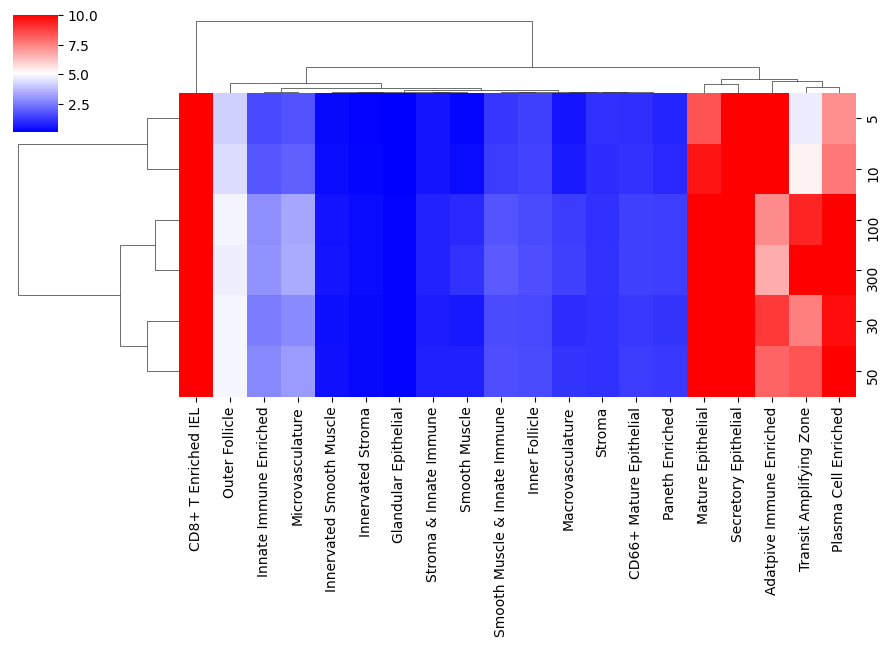

In [13]:
s=sns.clustermap(niche_comb, vmax=10, cmap = 'bwr', figsize=(9,6.5))
#plt.savefig(save_path+'Panethcell_percent_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [14]:
neigh_map = {
 'Transit Amplifying Zone': 'darkblue',
 'Microvasculature': 'black',
 'Adatpive Immune Enriched': 'orange',
 'Glandular Epithelial': 'darkorange',
 'CD66+ Mature Epithelial': 'firebrick',
 'Stroma & Innate Immune': 'brown',
 'CD8+ T Enriched IEL': 'green',
 'Mature Epithelial': 'magenta',
 'Innate Immune Enriched': 'skyblue',
 'Outer Follicle': 'navy',
 'Plasma Cell Enriched': 'yellow',
 'Innervated Stroma': 'blueviolet',
 'Stroma': 'gray',
 'Macrovasculature': 'gold',
 'Secretory Epithelial': 'yellowgreen',
 'Smooth Muscle': 'red',
 'Innervated Smooth Muscle': 'lightgreen',
 'Inner Follicle': 'blue',
 'Smooth Muscle & Innate Immune': 'tan',
 'Paneth Enriched': 'lightblue'}

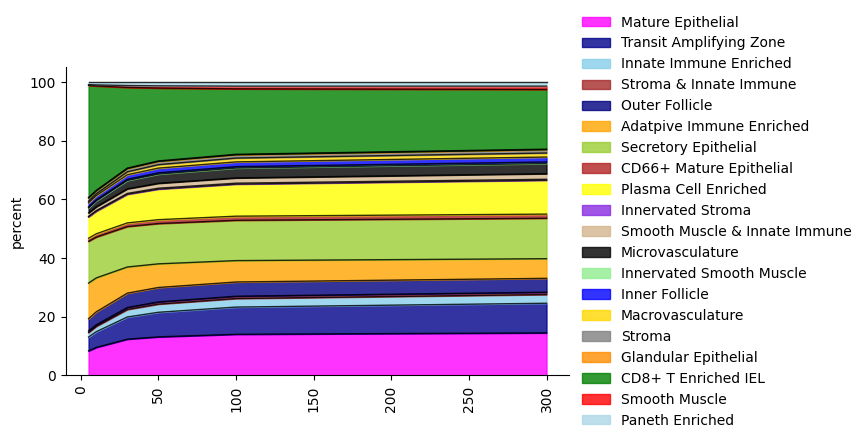

In [15]:
#first subplot
ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, color=[neigh_map.get(x) for x in niche_comb.columns],figsize =(6.5,4), rot=90)
# ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, figsize =(6.5,4), rot=90)
for line in ax1.lines:
    line.set_color('black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('percent')

lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)

#plt.savefig(save_path+'Panethcell_areaplot_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [16]:
#Check to make sure that correct values were obtained
celltype_windows[cluster_col].value_counts()

Neighborhood
CD8+ T Enriched IEL              85418
Secretory Epithelial             30275
Adatpive Immune Enriched         26760
Mature Epithelial                15695
Plasma Cell Enriched             15567
Transit Amplifying Zone           9590
Outer Follicle                    8885
Microvasculature                  3427
Innate Immune Enriched            3288
Inner Follicle                    2710
CD66+ Mature Epithelial           2408
Stroma                            2394
Smooth Muscle & Innate Immune     2229
Paneth Enriched                   1620
Macrovasculature                  1220
Stroma & Innate Immune            1060
Innervated Smooth Muscle           664
Innervated Stroma                  552
Smooth Muscle                      453
Glandular Epithelial               250
Name: count, dtype: int64

In [17]:
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-17-17a5b35a8002>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells[neighborhood_name] = labels


/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


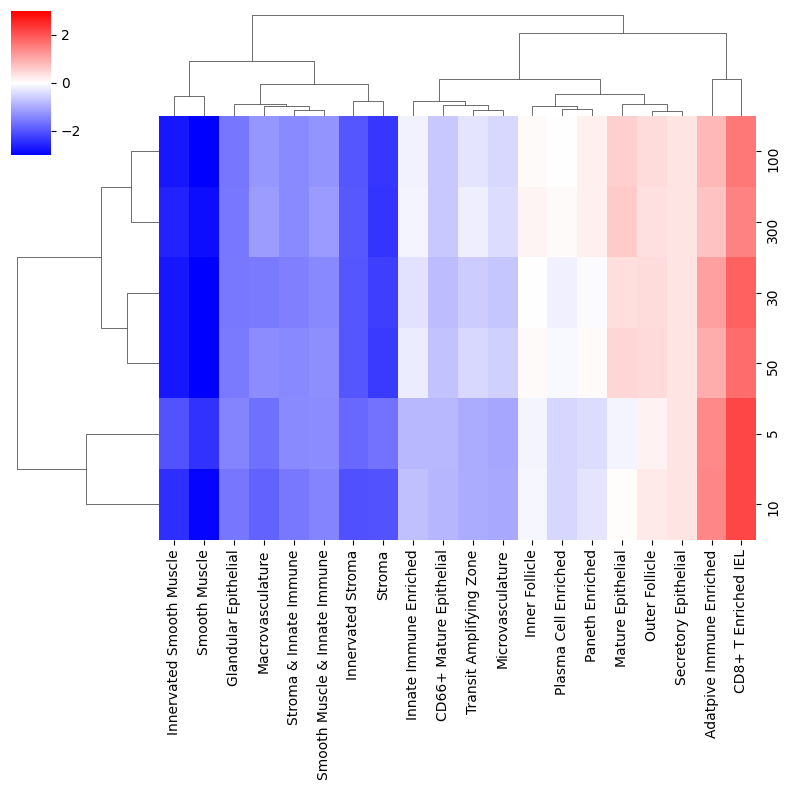

In [18]:
#this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr',square=True,cbar=True,figsize=(8,8))
#s.savefig(save_path+"celltypes_perniche_"+"_"+str(k)+".png", dpi=600)

#### UMAP visualization - neighborhoods

In [19]:
import scanpy as sc

##### Format data

In [20]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)
type_cells.columns

<ipython-input-20-4d117a24a9a6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)


Index(['Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f',
       'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR',
       'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90',
       'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34',
       'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117',
       'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163',
       'CD161', 'x', 'y', 'array', 'Xcorr', 'Ycorr', 'Tissue_location',
       'tissue', 'donor', 'unique_region', 'region', 'OLFM4', 'FAP', 'CD25',
       'CollIV', 'CK7', 'MUC6', 'Cell Type', 'Cell Type em', 'Cell subtype',
       'Neighborhood', 'Neigh_sub', 'Neighborhood_Ind', 'NeighInd_sub',
       'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit',
       'Adatpive Immune Enriched', 'CD66+ Mature Epithelial',
       'CD8+ T Enriched IEL', 'Glandular Epithelial', 'Innate Immune Enriched',
       'Inner Follicle', 'Innerva

In [21]:
markerlist = [
    'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
    'Tissue_location', 'array', 'Cell Type', 'Cell Type em','Cell subtype',
    'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
    'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment']

#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))

marker_df = type_cells[markerlist]


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T
#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()
#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])

marker_df.columns

<ipython-input-21-921b440fbc1c>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
<ipython-input-21-921b440fbc1c>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
<ipython-input-21-921b440fbc1c>:19: SettingWithCopyWarning: 
A value is trying to be set on a co

Index(['tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location',
       'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'Neighborhood',
       'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community',
       'Major Community', 'Tissue Segment', 'neighborhood50',
       'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone',
       'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune',
       'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched',
       'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial',
       'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma',
       'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature',
       'Enriched Innervated Smooth Muscle', 'Enriched Inner Follicle',
       'Enriched Macrovasculature', 'Enriched Stroma',
       'Enriched Glandular Epithelial', 'Enriched CD8+ T Enriched IEL',
       'Enriched Smooth Muscle', 'Enriched Paneth Enriched'],
      dtype='o

In [22]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)
comb_df

,x,y,unique_region,Neighborhood,Cell Type,Mature Epithelial,Transit Amplifying Zone,Innate Immune Enriched,Stroma & Innate Immune,Outer Follicle,...,Enriched Smooth Muscle & Innate Immune,Enriched Microvasculature,Enriched Innervated Smooth Muscle,Enriched Inner Follicle,Enriched Macrovasculature,Enriched Stroma,Enriched Glandular Epithelial,Enriched CD8+ T Enriched IEL,Enriched Smooth Muscle,Enriched Paneth Enriched
36246,134.0,295.0,B004_Ascending,CD8+ T Enriched IEL,CD8+ T,11.0,6.0,0.0,0.0,8.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
36247,278.0,155.0,B004_Ascending,Transit Amplifying Zone,CD8+ T,9.0,24.0,0.0,0.0,9.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
36248,449.0,448.0,B004_Ascending,Plasma Cell Enriched,CD8+ T,0.0,8.0,0.0,0.0,4.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
36249,482.0,49.0,B004_Ascending,Mature Epithelial,CD8+ T,3.0,39.0,0.0,0.0,0.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
36250,496.0,562.0,B004_Ascending,Plasma Cell Enriched,CD8+ T,0.0,0.0,0.0,0.0,0.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2593427,1205.0,5978.0,B008_Trans,Plasma Cell Enriched,CD8+ T,0.0,7.0,0.0,0.0,4.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
2593428,4562.0,4453.0,B008_Trans,Stroma & Innate Immune,CD8+ T,0.0,0.0,0.0,7.0,0.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
2593429,1630.0,7089.0,B008_Trans,Adatpive Immune Enriched,CD8+ T,0.0,0.0,1.0,0.0,0.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652
2593430,7402.0,177.0,B008_Trans,Smooth Muscle,CD8+ T,0.0,0.0,0.0,0.0,0.0,...,-1.328675,-0.548741,-2.729686,0.049871,-1.353831,-2.317094,-1.566849,1.732694,-3.178352,0.05652


In [23]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)
df['neighborhood'+str(k)]

36246      0
36247      0
36248      0
36249      0
36250      0
          ..
2593427    0
2593428    0
2593429    0
2593430    0
2593431    0
Name: neighborhood50, Length: 214465, dtype: object

In [24]:
cell_enr = [
    'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone',
       'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune',
       'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched',
       'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial',
       'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma',
       'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature',
       'Enriched Innervated Smooth Muscle', 'Enriched Inner Follicle',
       'Enriched Macrovasculature', 'Enriched Stroma',
       'Enriched Glandular Epithelial', 'Enriched CD8+ T Enriched IEL',
       'Enriched Smooth Muscle', 'Enriched Paneth Enriched'
]
collist = [
       'x', 'y', 'unique_region', 'tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell Type',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community','Tissue Segment'
 ]
#Prepare for making into anndata format so that obs and data are separate
windows_list = [
       'Mature Epithelial', 'Transit Amplifying Zone',
       'Innate Immune Enriched', 'Stroma & Innate Immune', 'Outer Follicle',
       'Adatpive Immune Enriched', 'Secretory Epithelial',
       'CD66+ Mature Epithelial', 'Plasma Cell Enriched', 'Innervated Stroma',
       'Smooth Muscle & Innate Immune', 'Microvasculature',
       'Innervated Smooth Muscle', 'Inner Follicle', 'Macrovasculature',
       'Stroma', 'Glandular Epithelial', 'CD8+ T Enriched IEL',
       'Smooth Muscle', 'Paneth Enriched',]

In [25]:
df1 = df.drop(columns = collist) #USER INPUT
df1.columns

Index(['Mature Epithelial', 'Transit Amplifying Zone',
       'Innate Immune Enriched', 'Stroma & Innate Immune', 'Outer Follicle',
       'Adatpive Immune Enriched', 'Secretory Epithelial',
       'CD66+ Mature Epithelial', 'Plasma Cell Enriched', 'Innervated Stroma',
       'Smooth Muscle & Innate Immune', 'Microvasculature',
       'Innervated Smooth Muscle', 'Inner Follicle', 'Macrovasculature',
       'Stroma', 'Glandular Epithelial', 'CD8+ T Enriched IEL',
       'Smooth Muscle', 'Paneth Enriched', 'Cell Type em', 'neighborhood50',
       'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone',
       'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune',
       'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched',
       'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial',
       'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma',
       'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature',
       'Enr

In [26]:
#Prepare for making into anndata format
dfw = df[windows_list]
dfw.columns

Index(['Mature Epithelial', 'Transit Amplifying Zone',
       'Innate Immune Enriched', 'Stroma & Innate Immune', 'Outer Follicle',
       'Adatpive Immune Enriched', 'Secretory Epithelial',
       'CD66+ Mature Epithelial', 'Plasma Cell Enriched', 'Innervated Stroma',
       'Smooth Muscle & Innate Immune', 'Microvasculature',
       'Innervated Smooth Muscle', 'Inner Follicle', 'Macrovasculature',
       'Stroma', 'Glandular Epithelial', 'CD8+ T Enriched IEL',
       'Smooth Muscle', 'Paneth Enriched'],
      dtype='object')

In [27]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]
adata_w

/usr/local/lib/python3.10/dist-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [36246, 36247, 36248, 36249, 36250]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 214465 × 20
    obs: 'x', 'y', 'unique_region', 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell Type', 'Cell Type', 'Cell subtype', 'Neighborhood', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone', 'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune', 'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched', 'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial', 'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma', 'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature', 'Enriched Innervated Smooth Muscle', 'Enriched Inner Follicle', 'Enriched Macrovasculature', 'Enriched Stroma', 'Enriched Glandular Epithelial', 'Enriched CD8+ T Enriched IEL', 'Enriched Smooth Muscle', 'Enriched Paneth Enriched'

##### Leiden clustering in replacement of K means

In [28]:
sc.settings.figdir='single_cell_neighborhood'
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1

/usr/local/lib/python3.10/dist-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packa

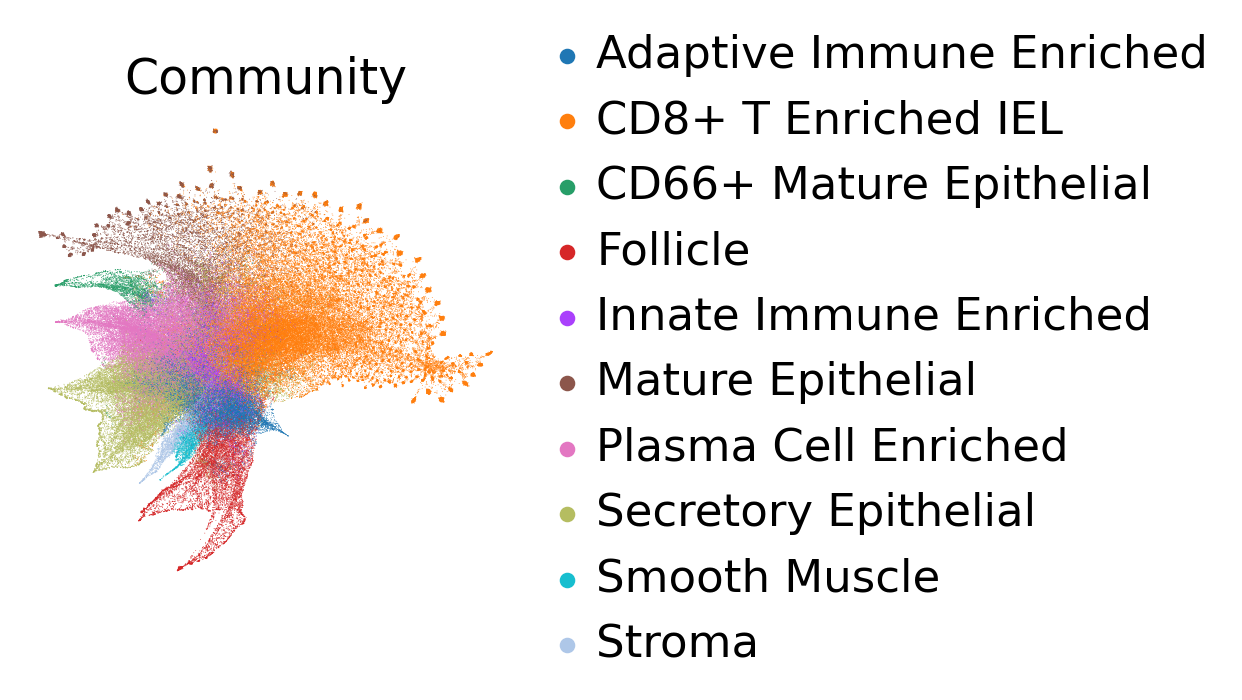

In [29]:
sc.pp.neighbors(adata_w, n_neighbors=20)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='Community',)

/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

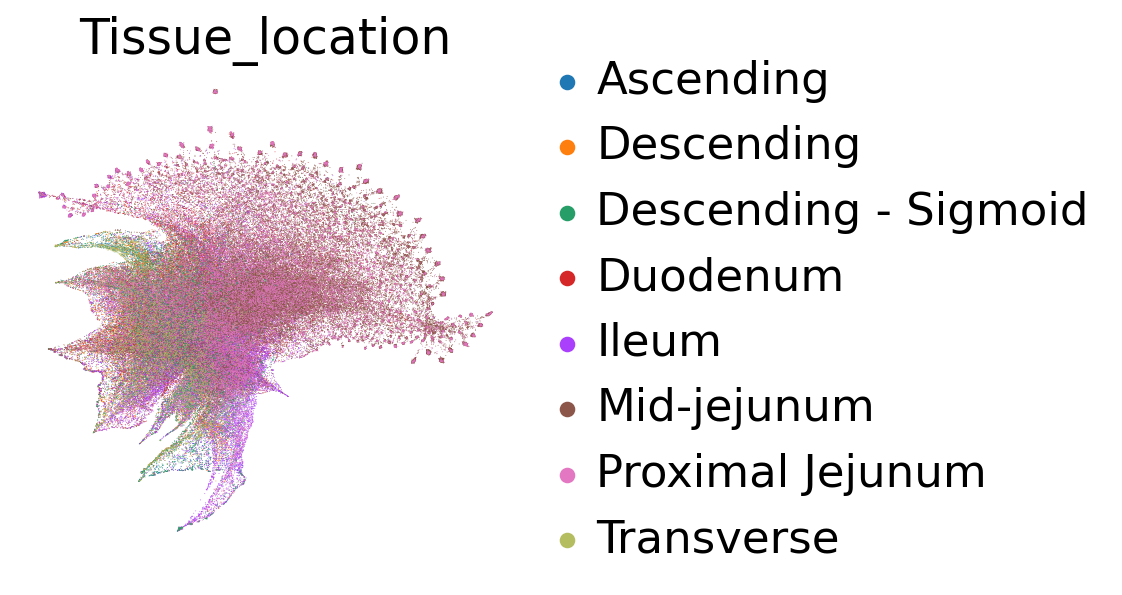

In [30]:
sc.pl.umap(adata_w, color ='Tissue_location',)